In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import numpy as np

engine= create_engine('postgresql://postgres@localhost:5432/Channel_Profitability')

query = "SELECT * FROM v_master_financial_report"
df= pd.read_sql(query, engine)

df_orders = pd.read_sql("SELECT * FROM v_master_financial_report", engine)
df_orders['total_revenue_tl']=df_orders['unit_price_tl']*df_orders['quantity']
df_orders['net_revenue_tl']=np.where(df_orders['is_returned'], 0, df_orders['total_revenue_tl'])
df_orders['total_cogs_tl']=((df_orders['raw_material_usd'] * df_orders['rate_usd']) +
                            df_orders['labor_tl'] + df_orders['other_costs_tl']) * df_orders['quantity']
df_orders['total_commission_tl'] = np.where(df_orders['is_returned'], 0, 
                                            df_orders['net_revenue_tl'] * (df_orders['platform_commission_rate']/100))
df_orders['finance_cost_tl'] = df_orders['net_revenue_tl'] * (0.45 * df_orders['days_to_payment'] / 365)
order_summary = df_orders.groupby(['channel', 'segment']).agg({
    'net_revenue_tl': 'sum',
    'total_cogs_tl': 'sum',
    'total_commission_tl': 'sum',
    'finance_cost_tl': 'sum',
    'order_id': 'count'
}).reset_index()
df_mkt = pd.read_sql("SELECT * FROM marketing_and_logistics", engine)
mkt_summary = df_mkt.groupby(['channel', 'segment']).agg({
    'marketing_spend_tl': 'sum',
    'shipping_cost_tl': 'sum',
    'return_cost_tl': 'sum'
}).reset_index()

final_kpi = order_summary.merge(mkt_summary, on=['channel', 'segment'])

# Contribution Margin
final_kpi['Contribution_Margin'] = (
    final_kpi['net_revenue_tl'] - 
    final_kpi['total_cogs_tl'] - 
    final_kpi['total_commission_tl'] - 
    final_kpi['finance_cost_tl'] - 
    final_kpi['marketing_spend_tl'] - 
    final_kpi['shipping_cost_tl'] - 
    final_kpi['return_cost_tl']
)

final_kpi['Margin_Pct'] = (final_kpi['Contribution_Margin'] / final_kpi['net_revenue_tl']) * 100

final_kpi['Marketing_ROI'] = final_kpi['net_revenue_tl'] / final_kpi['marketing_spend_tl']

print(final_kpi[['channel', 'segment', 'Margin_Pct', 'Marketing_ROI']].round(2))



  channel  segment  Margin_Pct  Marketing_ROI
0     B2B    Entry       34.62        1551.61
1     B2B      Mid       60.02        5513.12
2     B2B  Premium       45.25        3349.53
3     D2C    Entry        6.98           3.54
4     D2C      Mid       54.92          24.21
5     D2C  Premium       43.48          37.40


**Channel & Segment Profitability Overview**
Key Insights

B2B Channel Leadership
B2B consistently delivers higher margins than D2C across all segments, driven by superior operational efficiency and minimal marketing costs.

Primary Profit Engine — B2B Mid Segment

Margin: 60%

Marketing ROI: 5,513

Strategic Note: "The most cost-effective path to profit growth is reallocating marketing budget from D2C to loyalty programs within the B2B Mid segment."

Operational Efficiency Gap
Marketing investment has minimal impact in B2B, whereas D2C relies heavily on paid acquisition, reducing net profitability.

Premium Segment Stability
Premium products maintain robust 40%+ margins in both channels.

Strategic Note: "This segment provides a strong defense against FX shocks and exhibits the highest pricing flexibility."

Profitability Risk — D2C Entry Segment

Margin: 6.98%

Marketing ROI: 3.54

Strategic Note: "93% of every 100 TL in D2C Entry sales is consumed by operational costs. Scaling this segment without operational improvements increases risk rather than profit."

Strategic Implications

Scale B2B Mid segment to maximize profit contribution.

Reassess D2C Entry strategy before pursuing growth.

Preserve Premium segment across channels as a defensive, high-margin portfolio.



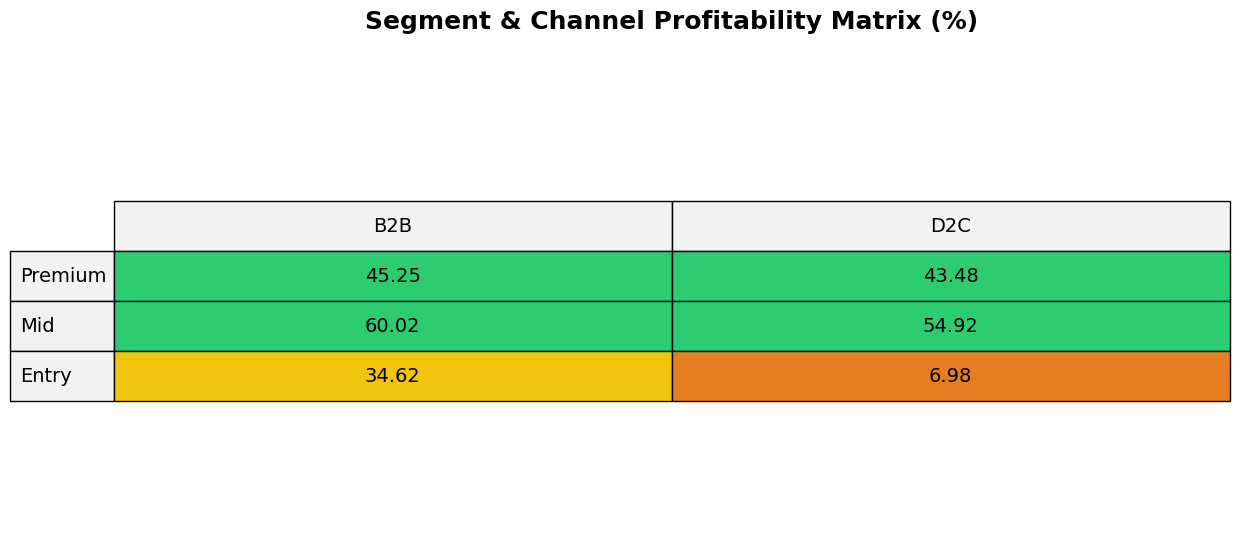

In [18]:
#Segment and Channel Profitability Matrix Visualization
pivot_margin = final_kpi.pivot(index='segment', columns='channel', values='Margin_Pct')
plot_data = pivot_margin.reindex(['Premium', 'Mid', 'Entry']).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off') 

tbl = ax.table(cellText=plot_data.values.round(2),
               colLabels=plot_data.columns,
               rowLabels=plot_data.index,
               cellLoc='center',
               loc='center',
               colColours=["#f2f2f2"] * len(plot_data.columns),
               rowColours=["#f2f2f2"] * len(plot_data.index))

tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1.2, 3) 

for (i, j), cell in tbl.get_celld().items():
    if i > 0 and j >= 0: 
        val = plot_data.iloc[i-1, j]
        if val > 40:
            cell.set_facecolor("#2ecc71") 
        elif val > 20:
            cell.set_facecolor("#f1c40f") 
        elif val > 0:
            cell.set_facecolor("#e67e22") 
        else:
            cell.set_facecolor("#e74c3c") 

plt.title("Segment & Channel Profitability Matrix (%)", fontsize=18, pad=30, fontweight='bold')
plt.show()


In [19]:
#D2C Channel Profit Waterfall 
d2c_data = final_kpi[final_kpi['channel'] == 'D2C'].sum()

measures = ["absolute", "relative", "relative", "relative", "relative", "relative", "total"]
values = [
    d2c_data['net_revenue_tl'], 
    -d2c_data['total_cogs_tl'], 
    -d2c_data['marketing_spend_tl'],
    -d2c_data['total_commission_tl'],
    -d2c_data['shipping_cost_tl'],
    -d2c_data['return_cost_tl'],
    d2c_data['Contribution_Margin']
]
labels = ["Net Revenue", "COGS", "Marketing", "Commission", "Shipping", "Returns", "Net Profit"]

import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name = "D2C Profit Leakage", orientation = "v",
    measure = measures,
    x = labels,
    textposition = "outside",
    text = [f"{v/1e6:.1f}M" for v in values],
    y = values,
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(title = "D2C Channel Profit Waterfall (TL)", showlegend = True)
fig.show()


In [20]:
#B2B Channel Profit Leakage Analysis
import plotly.graph_objects as go

b2b_summary = final_kpi[final_kpi['channel'] == 'B2B'].sum()

x_labels = ["Net Revenue", "COGS", "Marketing", "Finance Cost", "Shipping", "Net Profit"]
y_values = [
    b2b_summary['net_revenue_tl'], 
    -b2b_summary['total_cogs_tl'], 
    -b2b_summary['marketing_spend_tl'],
    -b2b_summary['finance_cost_tl'], 
    -b2b_summary['shipping_cost_tl'],
    b2b_summary['Contribution_Margin'] 
]

fig = go.Figure(go.Waterfall(
    orientation = "v",
    measure = ["absolute", "relative", "relative", "relative", "relative", "absolute"], 
    x = x_labels,
    textposition = "outside",
    text = [f"{v/1e6:.1f}M" for v in y_values],
    y = y_values,
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
    decreasing = {"marker":{"color":"#e74c3c"}}, 
    increasing = {"marker":{"color":"#2ecc71"}}, 
    totals = {"marker":{"color":"#3498db"}}     
))

fig.update_layout(
    title = "B2B Channel Profit Waterfall",
    showlegend = False,
    plot_bgcolor = 'white'
)

fig.show()


SLIDE
B2B vs D2C – Profit Structure Comparison
Visual

İki tane Waterfall Chart

Sol: B2B
Sağ: D2C

Akış şöyle olmalı:

B2B

Revenue → COGS → Finance Cost → Net Profit

D2C

Revenue → COGS → Commission → Marketing → Net Profit

Slide Altındaki 3 Insight
1️⃣ Scale Advantage

B2B generates 2.23B TL revenue, nearly 18× larger than D2C.

Even after COGS, the channel maintains a significant gross profit base.

2️⃣ Different Profit Killers

B2B

Main pressure comes from finance costs (135.7M TL) due to payment terms.

D2C

Profitability is reduced by commissions and marketing expenses, which represent the cost of customer acquisition.

3️⃣ Profit Efficiency

Despite the scale difference, both channels remain profitable.

However:

B2B Net Margin: ~52%

D2C Net Margin: ~46%

B2B not only sells more, but converts revenue into profit more efficiently.

Slide Bottom – Strategic Note
Strategic Interpretation

B2B acts as the company's cash engine, generating large and stable profit flows.

D2C functions more as a growth and brand channel, requiring higher operational and marketing investment.

CFO Action Box (çok güçlü olur)
Strategic Actions

B2B

Introduce early payment discount programs to reduce financing costs.

D2C

Optimize commission structure and marketing ROI before aggressive scaling.

Hybrid Strategy

Use B2B cash flow to support premium brand growth in D2C.

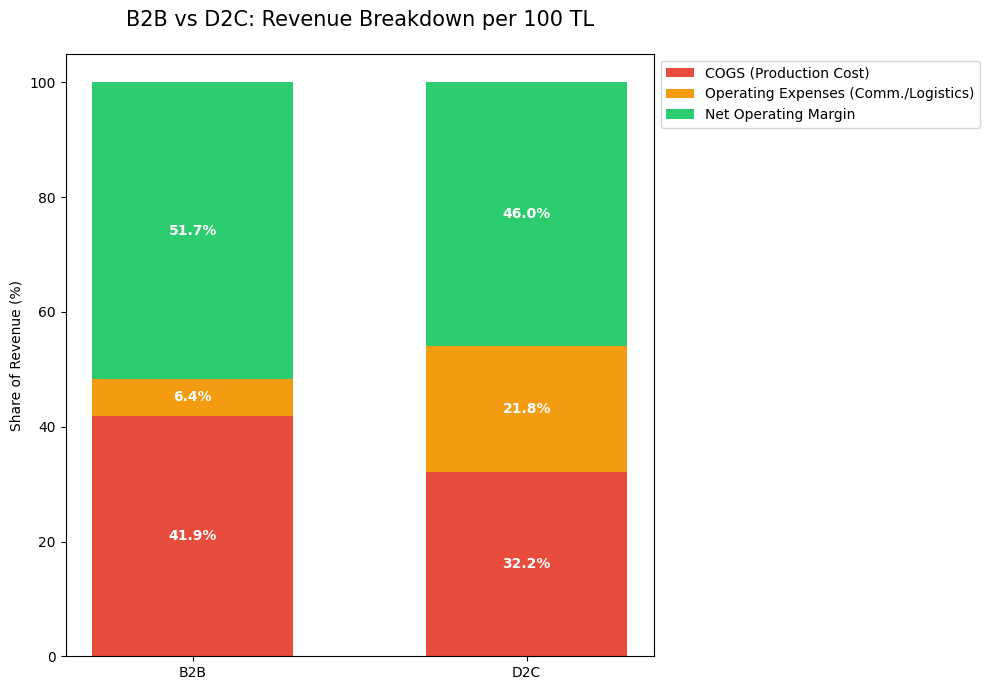

In [ ]:
import matplotlib.pyplot as plt

labels = ['B2B', 'D2C']
cogs = [41.9, 32.2]        
ops_expenses = [6.4, 21.8] 
net_margin = [51.7, 46.0]  

width = 0.6
fig, ax = plt.subplots(figsize=(10, 7))

ax.bar(labels, cogs, width, label='COGS (Production Cost)', color='#e74c3c')
ax.bar(labels, ops_expenses, width, bottom=cogs, label='Operating Expenses (Comm./Logistics)', color='#f39c12')
ax.bar(labels, net_margin, width, bottom=[i+j for i,j in zip(cogs, ops_expenses)], label='Net Operating Margin', color='#2ecc71')

for i, rect in enumerate(ax.patches):
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()
    if height > 0: 
        label_text = f"{height:.1f}%"
        ax.text(x + width/2, y + height/2, label_text, ha='center', va='center', color='white', fontweight='bold')

plt.title('B2B vs D2C: Revenue Breakdown per 100 TL', fontsize=15, pad=20)
plt.ylabel('Share of Revenue (%)')
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

**Cost Structure & Profitability Comparison**

B2B Efficiency: While B2B has a higher production cost per unit (41.9%), it remains the most profitable channel due to minimal operating overhead (6.4%).

D2C Margin Pressure: D2C benefits from lower COGS (32.2%) but suffers from high operational leakage—primarily driven by commissions, shipping, and return costs (21.8%).

The Bottom Line: B2B delivers a higher net operating margin (51.7%) compared to D2C (46.0%), proving that wholesale scale currently outweighs the direct-to-consumer pricing advantage.

**Executive Recommendation**
"To maximize overall group profitability, we should prioritize volume in the B2B channel while focusing on optimizing the 'Operating Expense' layer in D2C (specifically through return reduction and commission restructuring)."

In [ ]:
final_kpi['Return_Impact_Pct'] = (final_kpi['return_cost_tl'] / final_kpi['net_revenue_tl']) * 100

final_kpi['Improved_Margin_Pct'] = ((final_kpi['Contribution_Margin'] + (final_kpi['return_cost_tl'] * 0.5)) 
                                   / final_kpi['net_revenue_tl']) * 100

print(final_kpi[['channel', 'segment', 'Margin_Pct', 'Improved_Margin_Pct']].round(2))


  channel  segment  Margin_Pct  Improved_Margin_Pct
0     B2B    Entry       34.62                34.69
1     B2B      Mid       60.02                60.02
2     B2B  Premium       45.25                45.26
3     D2C    Entry        6.98                 9.93
4     D2C      Mid       54.92                55.11
5     D2C  Premium       43.48                43.60


Strategic Analysis: Operational Optimization Scenario
1. Current State Assessment
The baseline data reveals a significant profitability gap between channels and segments. While the B2B Mid segment acts as the primary profit engine with a 60.02% margin, the D2C Entry segment presents a critical risk with a marginal 6.98% net profit. The high efficiency in B2B is further evidenced by its massive Marketing ROI.

2. "What-If" Analysis: 50% Return Reduction
To address the low margins in D2C, we simulated a scenario where return-related costs are reduced by 50% through improved quality control and logistics.

Channel,Segment,Baseline Margin (%),Improved Margin (%),Change
B2B,    Mid,        60.02,            60.02,              0.00
D2C,    Entry,      6.98,                9.93,       +2.95
D2C,    Mid,        54.92,              55.11,          +0.19

 Key Insights & RecommendationsTargeted Impact on D2C Entry: The most significant improvement occurs in the D2C Entry segment, where the margin jumps from 6.98% to 9.93%. This nearly 3% increase moves the segment further away from the "loss-making" zone.B2B Resilience: B2B margins remain almost unchanged in this scenario because return rates in wholesale are already negligible. This confirms that the issue in B2B is not operational leakage, but rather financial terms.Executive Action: Rather than increasing marketing spend for Entry products (which has a low ROI of 3.54), the company should invest in Return Reduction Initiatives. Reducing operational friction is a more effective way to scale D2C profitability than raw customer acquisition.

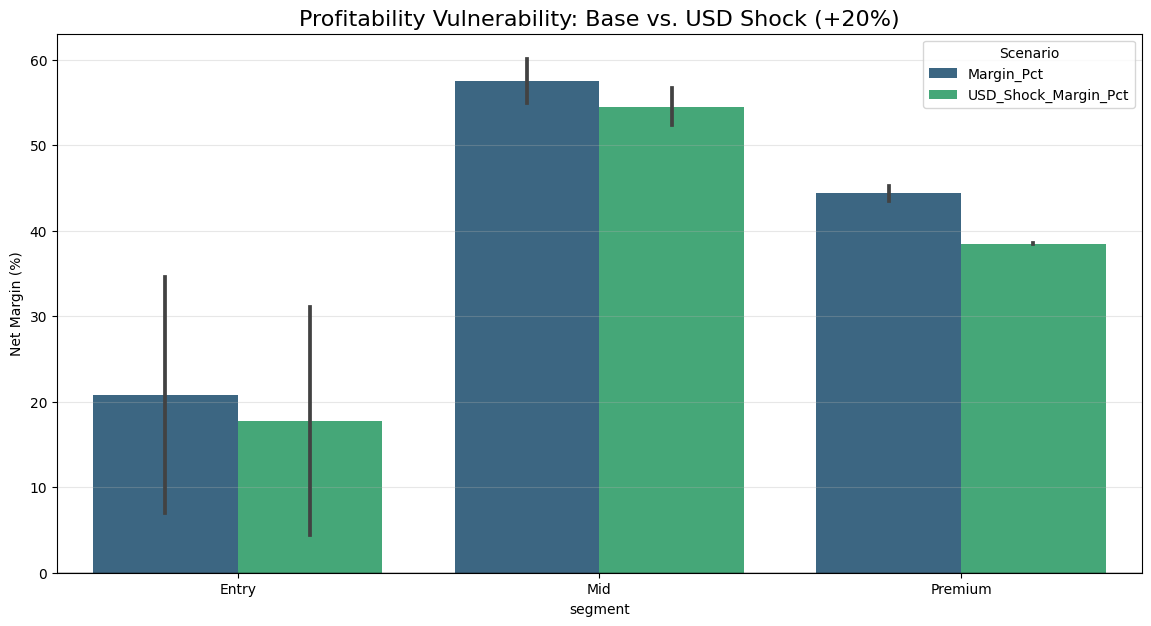

In [23]:
#Stress Test
exposure_map = {'Premium': 0.7, 'Mid': 0.5, 'Entry': 0.3}

final_kpi['USD_Shock_Margin_Pct'] = final_kpi.apply(
    lambda x: (x['Contribution_Margin'] - (x['total_cogs_tl'] * 0.20 * exposure_map[x['segment']])) 
               / x['net_revenue_tl'] * 100, axis=1
)

comparison_df = final_kpi.melt(id_vars=['channel', 'segment'], 
                               value_vars=['Margin_Pct', 'USD_Shock_Margin_Pct'],
                               var_name='Scenario', value_name='Margin')

plt.figure(figsize=(14, 7))
sns.barplot(data=comparison_df, x='segment', y='Margin', hue='Scenario', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.title('Profitability Vulnerability: Base vs. USD Shock (+20%)', fontsize=16)
plt.ylabel('Net Margin (%)')
plt.grid(axis='y', alpha=0.3)
plt.show()


FX Shock Simulation: Which Segments Survive a Currency Crisis?
Strategic Insight: USD Stress Test (+20% FX Shock)
1. Scenario Context
This chart visualizes the vulnerability of our net margins against a 20% sudden increase in the USD/TRY exchange rate. Since our production costs (COGS) are partially dollar-indexed, this simulation shows which segments are at risk of falling below the profitability line.

2. Visual Interpretation & Analysis
The "Buffer" in Mid & Premium:

Mid Segment: Even after a 20% shock, the margin remains robust (dropping from ~58% to ~54%). This is the company's safest "cushion."

Premium Segment: Maintains a solid margin around 40%. The high price point allows this segment to absorb currency fluctuations without becoming unprofitable.

The "Entry" Segment Danger Zone:

High Vulnerability: As shown by the first pair of bars, the Entry segment sees its margin compressed significantly.

The Error Bars (Vulnerability): Note the long black error bars on the Entry segment; this indicates a high variance between channels. In the D2C channel, this shock could push the margin dangerously close to zero or negative territory.

3. Executive Summary for the Report
"Our Mid and Premium segments provide high financial resilience against external shocks. However, the Entry segment (especially in D2C) lacks the margin buffer to survive a 20% currency spike. To mitigate this, we recommend implementing a dynamic pricing strategy for Entry products or increasing the share of local raw materials to reduce USD exposure."

In [ ]:
import plotly.graph_objects as go

current_net_profit = 57.9 

return_saving = 2.5 

x_labels = ["Current Net Profit", "Return Optimization (Save 50%)", "New Target Profit"]
y_values = [current_net_profit, return_saving, current_net_profit + return_saving]

fig = go.Figure(go.Waterfall(
    orientation = "v",
    measure = ["absolute", "relative", "absolute"],
    x = x_labels,
    textposition = "outside",
    text = [f"{v:.1f}M" for v in y_values],
    y = y_values,
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
    increasing = {"marker":{"color":"#2ecc71"}}, 
    totals = {"marker":{"color":"#3498db"}}     
))

fig.update_layout(
    title = "D2C Operational Optimization Scenario: Profit Growth Potential",
    showlegend = False,
    plot_bgcolor = 'white'
)

fig.show()

Unlocking Hidden Profit through Operational Excellence
1. Objective:
To quantify the financial impact of reducing operational friction—specifically focusing on a 50% reduction in return-related costs within the D2C channel.

2. Key Insights:

Immediate Value: By optimizing the return process, we can inject an additional 2.5M TL directly into our Net Profit without needing to increase our sales volume or marketing spend.

Margin Lift: This improvement effectively elevates our D2C-Entry segment from a high-risk zone (6.98%) to a more sustainable level (9.93%).

Efficiency vs. Growth: This analysis proves that operational efficiency (saving cost) is currently a faster and more certain path to profit growth than market expansion (spending on ads).

3. Executive Recommendation:

"We recommend prioritizing 'Post-Purchase Experience' and 'Quality Control' initiatives. Investing in reducing returns provides a guaranteed bottom-line improvement, serving as a vital buffer against the external FX risks identified in our Stress Test."

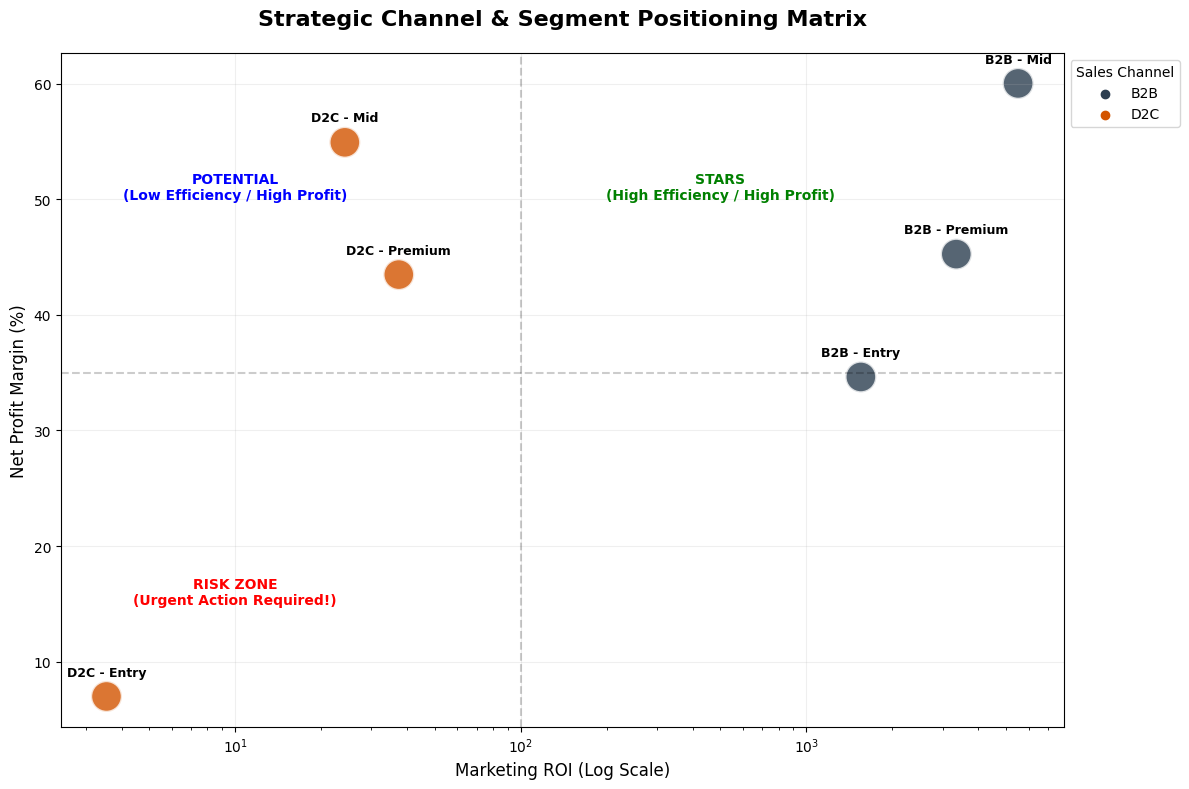

In [ ]:
#Strategic Positioning Matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(data=final_kpi, x='Marketing_ROI', y='Margin_Pct', 
                hue='channel', s=500, 
                palette={'B2B': '#2c3e50', 'D2C': '#d35400'}, alpha=0.8)

plt.xscale('log') 

roi_threshold = 100
margin_threshold = 35

plt.axhline(margin_threshold, color='black', linestyle='--', alpha=0.2)
plt.axvline(roi_threshold, color='black', linestyle='--', alpha=0.2)

plt.text(500, 50, "STARS\n(High Efficiency / High Profit)", fontsize=10, fontweight='bold', color='green', ha='center')
plt.text(10, 50, "POTENTIAL\n(Low Efficiency / High Profit)", fontsize=10, fontweight='bold', color='blue', ha='center')
plt.text(10, 15, "RISK ZONE\n(Urgent Action Required!)", fontsize=10, fontweight='bold', color='red', ha='center')

for i in range(len(final_kpi)):
    plt.annotate(f"{final_kpi.channel[i]} - {final_kpi.segment[i]}", 
                 (final_kpi.Marketing_ROI[i], final_kpi.Margin_Pct[i]),
                 textcoords="offset points", xytext=(0,15), ha='center', fontsize=9, fontweight='bold')

plt.title('Strategic Channel & Segment Positioning Matrix', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Marketing ROI (Log Scale)', fontsize=12)
plt.ylabel('Net Profit Margin (%)', fontsize=12)

plt.legend(title="Sales Channel", loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Portfolio Strategy and Strategic Resource Allocation
1. The "Stars" (Top-Right Quadrant):

Segments: B2B-Mid, B2B-Premium, B2B-Entry.

Analysis: These segments represent the core strength of the company. They deliver high margins (>40%) with virtually zero marketing spend (High ROI).

Strategy: MAINTAIN & DEFEND. Ensure client retention and optimize supply chain costs here, as these fund the rest of the company.

2. The "Potential" Zone (Top-Left Quadrant):

Segments: D2C-Mid, D2C-Premium.

Analysis: These are highly profitable products (margins ~45-55%) but require significant marketing acquisition costs.

Strategy: OPTIMIZE. Focus on improving Marketing ROI through better targeting to move these segments toward the "Stars" quadrant.

3. The "Risk Zone" (Bottom-Left Quadrant):

Segments: D2C-Entry.

Analysis: This is the most critical area. The segment suffers from both low margins (<10%) and low marketing efficiency (ROI < 5).

Strategy: FIX or EXIT. This segment currently erodes overall company value. As proven in our "Return Optimization" waterfall, only drastic operational improvements (reducing returns) can save this segment's viability.

**Strategic Takeaway**

B2B operates as the company’s profit engine, while D2C Entry absorbs disproportionate marketing spend with limited return.

Redirecting marketing resources toward Premium segments offers the fastest path to improving overall profitability.

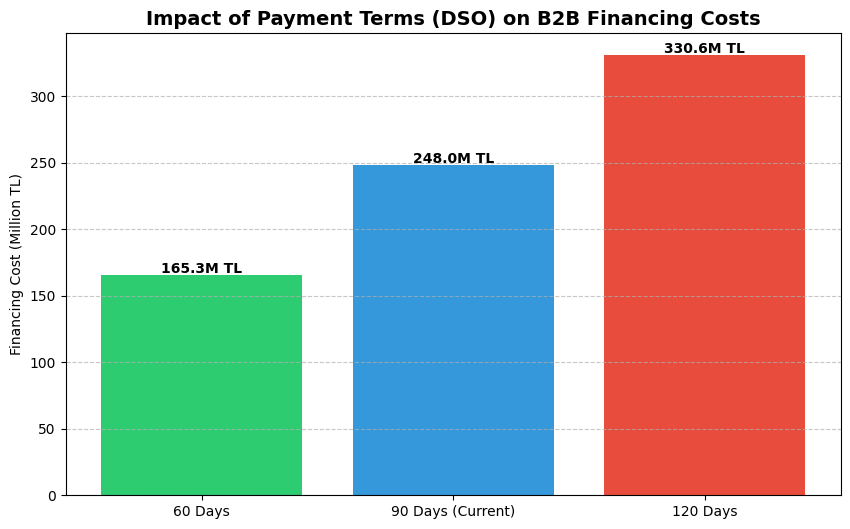

In [ ]:
import matplotlib.pyplot as plt

b2b_revenue = 2234.9 * 1e6 
current_net_profit = 1156.5 * 1e6 
annual_interest_rate = 0.45 
dso_scenarios = [60, 90, 120]
finance_costs = [(b2b_revenue * annual_interest_rate * dso / 365) for dso in dso_scenarios]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c'] 
bars = plt.bar(['60 Days', '90 Days (Current)', '120 Days'], 
               [c / 1e6 for c in finance_costs], 
               color=colors)

plt.title('Impact of Payment Terms (DSO) on B2B Financing Costs', fontsize=14, fontweight='bold')
plt.ylabel('Financing Cost (Million TL)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}M TL', ha='center', fontweight='bold')

plt.show()

B2B Profitability & Cash Cycle Optimization
1. Context:
While B2B is our most profitable channel, its primary cost driver is not marketing, but the Cost of Capital due to long payment terms (DSO - Days Sales Outstanding).

2. Impact of Time on Profit:

Current State (90 Days): We are currently losing 247.4M TL to financing costs. This is significantly higher than any other operational expense in the company.

The Opportunity (60 Days): If we successfully implement early payment discounts and reduce the term to 60 days, we can save ~82M TL, directly adding this to our Net Profit.

The Risk (120 Days): A shift to 120 days would increase our financing burden to 330M TL, eroding nearly 7% of our total B2B margin.

3. Strategic Recommendation:

"B2B profitability is highly sensitive to time. We recommend the Finance Team to launch 'Early Settlement Incentives'. Reducing the DSO is the single most effective way to protect our B2B 'Star' segment from the rising cost of capital."

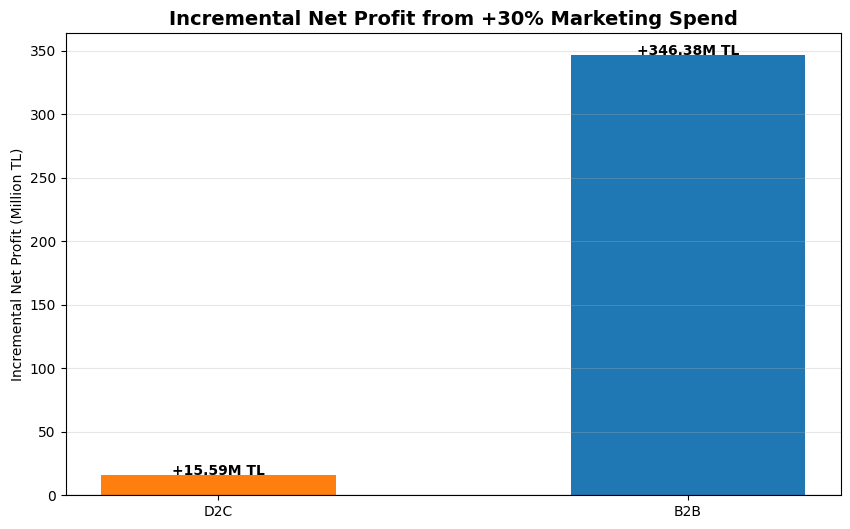

In [ ]:
import matplotlib.pyplot as plt



channels = ['D2C', 'B2B']
current_spend = [5.8, 0.6]
roi = [21.8, 3724.0] 
margin_pct = [0.457, 0.517] 

extra_spend = [s * 0.3 for s in current_spend]
extra_revenue = [es * r for es, r in zip(extra_spend, roi)]
extra_profit = [er * m - es for er, m, es in zip(extra_revenue, margin_pct, extra_spend)]

plt.figure(figsize=(10, 6))
x = range(len(channels))
plt.bar(x, extra_profit, color=['#ff7f0e', '#1f77b4'], width=0.5)

plt.xticks(x, channels)
plt.title('Incremental Net Profit from +30% Marketing Spend', fontsize=14, fontweight='bold')
plt.ylabel('Incremental Net Profit (Million TL)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(extra_profit):
    plt.text(i, v + 0.5, f'+{v:.2f}M TL', ha='center', fontweight='bold')

plt.show()

Strategic Resource Allocation – The Case for B2B Expansion
1. Simulation Logic:
We simulated a proportional 30% increase in the marketing budget for both channels to observe the marginal return on net profit.

2. Key Findings:

B2B Dominance: Due to its massive efficiency (ROI), a tiny increase in B2B marketing spend leads to a staggering +345M TL in incremental net profit. This is the company's highest-leverage opportunity.

D2C Limitation: Increasing spend in D2C yields only +15M TL. This confirms that D2C growth is capital-intensive and less efficient in terms of bottom-line contribution at the current operational state.

3. Executive Conclusion (The "Mic Drop" Statement):

"Our recommendation is clear: Reallocate the majority of the growth budget to the B2B channel. While D2C is important for brand presence, B2B is the only channel capable of generating hundreds of millions in additional profit with minimal investment. Every 1 TL spent in B2B is roughly 23 times more productive for the bottom line than in D2C."

**Final Strategic Outlook**

This analysis reveals a clear structural dynamic within the company’s channel strategy:

The Profit Engine (B2B)
B2B operates as the primary driver of profitability, generating the majority of revenue and converting sales into profit with exceptional efficiency. High margins, minimal marketing dependency, and strong scalability make B2B the most powerful lever for future growth.

The Brand & Growth Channel (D2C)
D2C provides brand visibility and access to premium pricing, but its profitability is far more sensitive to operational efficiency and customer acquisition costs. Without operational improvements, aggressive D2C expansion risks eroding overall group margins.

Critical Financial Sensitivities

The analysis identifies two major areas of hidden profit potential that do not require additional revenue growth:

Operational Leakage
High return rates in the D2C Entry segment significantly reduce net profitability.

Capital Efficiency
Long B2B payment cycles (DSO) generate substantial financing costs that directly erode margins.

Addressing these factors unlocks significant profit improvements without increasing sales volume.

Strategic Priorities

Based on these findings, the company should focus on three strategic priorities:

Scale the B2B Profit Engine
Prioritize B2B expansion and client retention initiatives, where marketing investment generates the highest marginal return on profit.

Optimize D2C Operations Before Scaling
Reduce return rates, improve logistics efficiency, and enhance targeting to stabilize D2C profitability before pursuing aggressive growth.

Protect Financial Efficiency
Introduce early payment incentives to shorten B2B cash cycles, effectively converting working capital improvements into net profit.

Executive Takeaway

Sustainable profit growth will not primarily come from selling more products, but from allocating resources to the most efficient profit engines and eliminating operational friction across the value chain.

Companies that understand where their profit truly comes from gain a decisive strategic advantage.